<a href="https://colab.research.google.com/github/VitorSoaresGoncalves/CalculoNumerico/blob/main/Atv2_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identificação e divisão de tarefas

**Integrante:**

- Vitor Soares Gonçalves - RA: 17654

## 1. Verificação da estabilidade

Para verificar a estabilidade do método numérico, inicialmente calculamos o espaçamento espacial da malha:

$$
\Delta y = \frac{H}{N-1}
$$

Considerando \(H=0,01\) m e \(N=21\) pontos:

$$
\Delta y = \frac{0,01}{21-1}
$$

$$
\boxed{\Delta y = 0,0005\text{ m}}
$$

Para o método explícito utilizado, a condição de estabilidade é:

$$
r = \frac{\nu\Delta t}{(\Delta y)^2} \leq \frac{1}{2}
$$

Dessa relação, podemos determinar o maior passo de tempo permitido:

$$
\Delta t_{\max} = \frac{(\Delta y)^2}{2\nu}
$$

Como \(\nu=10^{-4}\text{ m}^2/\text{s}\):

$$
\Delta t_{\max}
=
\frac{(0,0005)^2}{2(10^{-4})}
$$

$$
\boxed{\Delta t_{\max}=0,00125\text{ s}}
$$

### Caso A — \(\Delta t=0,001\) s

Calculando o valor de \(r\):

$$
r =
\frac{10^{-4}(0,001)}
{(0,0005)^2}
$$

$$
\boxed{r=0,4}
$$

Como:

$$
0,4 < 0,5
$$

o caso A satisfaz a condição de estabilidade:

$$
\boxed{\text{Caso A: ESTÁVEL}}
$$

Portanto, espera-se que a solução numérica permaneça limitada e apresente um comportamento compatível com a evolução física do problema.

### Caso B — \(\Delta t=0,002\) s

Calculando novamente \(r\):

$$
r =
\frac{10^{-4}(0,002)}
{(0,0005)^2}
$$

$$
\boxed{r=0,8}
$$

Como:

$$
0,8 > 0,5
$$

o caso B não satisfaz a condição de estabilidade:

$$
\boxed{\text{Caso B: INSTÁVEL}}
$$

Nesse caso, espera-se que os erros numéricos sejam amplificados durante as iterações. A velocidade pode crescer artificialmente, assumindo valores muito superiores ao limite físico de \(U=1\) m/s, podendo eventualmente ocorrer overflow.

### Resultado da análise

| Caso | \(\Delta t\) (s) | \(\Delta y\) (m) | \(\Delta t_{\max}\) (s) | \(r\) | Classificação |
| ---- | ---------------: | ---------------: | ----------------------: | ----: | ------------- |
| A    |            0,001 |           0,0005 |                 0,00125 |   0,4 | **Estável**   |
| B    |            0,002 |           0,0005 |                 0,00125 |   0,8 | **Instável**  |

Assim, antes mesmo da execução do programa, é possível prever que o **Caso A será estável**, pois \(r=0,4\leq0,5\), enquanto o **Caso B será instável**, pois \(r=0,8>0,5\). A diferença de comportamento não é causada pelo tipo numérico utilizado, mas pela escolha do passo de tempo em relação ao espaçamento da malha.


Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308

Análise de estabilidade - 21 pontos
Δy       = 0.00050000 m
Δt       = 0.00100000 s
Δt máximo = 0.00125000 s
r        = 0.4000
Resultado = ESTÁVEL

✓ Simulação concluída:
Tipo: float32
dt = 0.001
2000 passos sem overflow.

Análise de estabilidade - 21 pontos
Δy       = 0.00050000 m
Δt       = 0.00200000 s
Δt máximo = 0.00125000 s
r        = 0.8000
Resultado = INSTÁVEL

 Overflow/falha numérica!
Tipo: float32
dt = 0.002
Passo = 121
t = 0.242000 s
Erro: overflow encountered in subtract

Análise de estabilidade - 21 pontos
Δy       = 0.00050000 m
Δt       = 0.00100000 s
Δt máximo = 0.00125000 s
r        = 0.4000
Resultado = ESTÁVEL

✓ Simulação concluída:
Tipo: float64
dt = 0.001
2000 passos sem overflow.

Análise de estabilidade - 21 pontos
Δy       = 0.00050000 m
Δt       = 0.00200000 s
Δt máximo = 0.00125000 s
r        = 0.8000
Resultado = INSTÁVEL

 Overflow/falha numérica!
Tipo: float64
dt = 0.002
Passo = 917
t = 1.

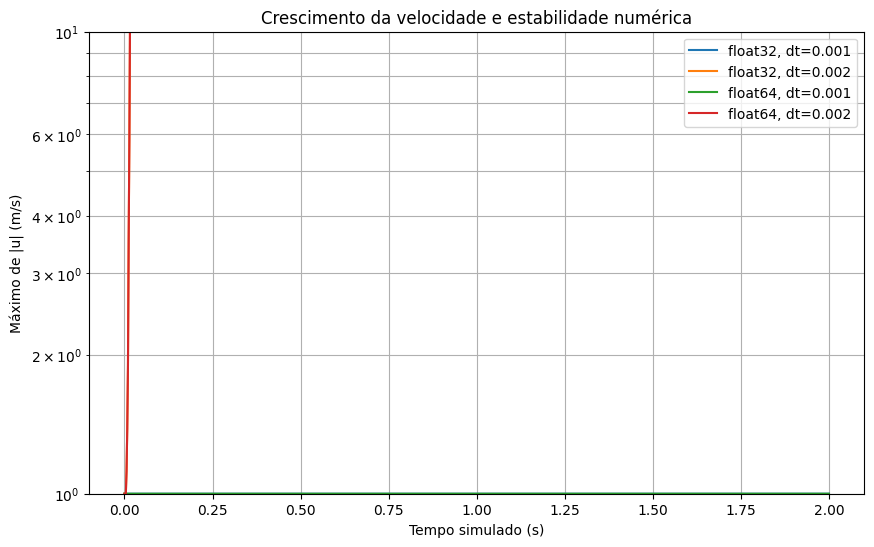

In [15]:
import numpy as np
import matplotlib.pyplot as plt


def verificar_estabilidade(dt, pontos=21):
    # Constantes do problema
    H = 0.01
    nu = 1e-4

    # Espaçamento da malha
    dy = H / (pontos - 1)

    # Maior passo de tempo permitido
    dt_max = (dy ** 2) / (2 * nu)

    # Número de estabilidade
    r = nu * dt / (dy ** 2)

    # Classificação
    if r <= 0.5:
        estabilidade = "ESTÁVEL"
    else:
        estabilidade = "INSTÁVEL"

    print("\n" + "=" * 55)
    print(f"Análise de estabilidade - {pontos} pontos")
    print("=" * 55)
    print(f"Δy       = {dy:.8f} m")
    print(f"Δt       = {dt:.8f} s")
    print(f"Δt máximo = {dt_max:.8f} s")
    print(f"r        = {r:.4f}")
    print(f"Resultado = {estabilidade}")
    print("=" * 55)

    return dy, dt_max, r, estabilidade


def simular(dt, tipo=np.float32, passos=2000, pontos=21):

    H = 0.01
    nu = 1e-4

    # Calcula e mostra a estabilidade antes da simulação
    dy, dt_max, r, estabilidade = verificar_estabilidade(
        dt, pontos
    )

    y = np.linspace(0, H, pontos)

    # Coeficientes no tipo numérico escolhido
    r = tipo(r)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]

    falha = None

    # Transforma avisos numéricos em exceções
    with np.errstate(over="raise", invalid="raise"):

        for passo in range(1, passos + 1):

            try:
                novo = u.copy()

                # Atualização da equação de difusão
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:]
                        - dois * u[1:-1]
                        + u[:-2]
                    )
                )

                # Verifica se apareceram valores infinitos ou NaN
                if not np.all(np.isfinite(novo)):
                    raise FloatingPointError(
                        "valor infinito ou NaN encontrado"
                    )

            except FloatingPointError as erro:

                falha = passo

                print(
                    f"\n Overflow/falha numérica!"
                    f"\nTipo: {tipo.__name__}"
                    f"\ndt = {dt}"
                    f"\nPasso = {passo}"
                    f"\nt = {passo * dt:.6f} s"
                    f"\nErro: {erro}"
                )

                break

            u = novo

            tempos.append(passo * dt)
            maximos.append(
                float(np.max(np.abs(u)))
            )

    if falha is None:

        print(
            f"\n✓ Simulação concluída:"
            f"\nTipo: {tipo.__name__}"
            f"\ndt = {dt}"
            f"\n{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "dy": dy,
        "dt_max": dt_max,
        "r": float(r),
        "estabilidade": estabilidade,
        "falha": falha,
    }


# ============================================================
# LIMITES DOS TIPOS NUMÉRICOS
# ============================================================

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)


# ============================================================
# EXECUÇÃO DOS QUATRO TESTES
# ============================================================

resultados = {}

for tipo in (np.float32, np.float64):

    for dt in (0.001, 0.002):

        nome = f"{tipo.__name__}, dt={dt}"

        resultados[nome] = simular(
            dt=dt,
            tipo=tipo,
            pontos=21
        )


# ============================================================
# TABELA FINAL
# ============================================================

print("\n\n")
print("=" * 85)
print("TABELA DE RESULTADOS")
print("=" * 85)

print(
    f"{'Tipo':<12}"
    f"{'dt (s)':<12}"
    f"{'Δy (m)':<15}"
    f"{'dt máx. (s)':<15}"
    f"{'r':<10}"
    f"{'Estabilidade':<15}"
    f"{'Overflow':<10}"
)

print("-" * 85)

for nome, resultado in resultados.items():

    tipo = nome.split(",")[0]
    dt = float(nome.split("=")[-1])

    overflow = (
        "Sim"
        if resultado["falha"] is not None
        else "Não"
    )

    print(
        f"{tipo:<12}"
        f"{dt:<12.4f}"
        f"{resultado['dy']:<15.8f}"
        f"{resultado['dt_max']:<15.8f}"
        f"{resultado['r']:<10.3f}"
        f"{resultado['estabilidade']:<15}"
        f"{overflow:<10}"
    )


# ============================================================
# GRÁFICO
# ============================================================

plt.figure(figsize=(10, 6))

for nome, resultado in resultados.items():

    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s)")
plt.title("Crescimento da velocidade e estabilidade numérica")
plt.grid(True, which="both")
plt.legend()

plt.show()

In [16]:
# ============================================================
# TABELA SOLICITADA NA ATIVIDADE
# ============================================================

print("\n")
print("=" * 85)
print("TABELA - DETECÇÃO DE OVERFLOW")
print("=" * 85)

print(
    f"{'Tipo numérico':<16}"
    f"{'Δt (s)':<12}"
    f"{'r':<10}"
    f"{'Overflow':<12}"
    f"{'Iteração da falha':<20}"
)

print("-" * 85)

for nome, resultado in resultados.items():

    # Recupera o tipo e o dt a partir do nome
    tipo = nome.split(",")[0]
    dt = float(nome.split("=")[-1])

    # Verifica se ocorreu overflow
    if resultado["falha"] is not None:
        overflow = "Sim"
        iteracao = resultado["falha"]
    else:
        overflow = "Não"
        iteracao = "-"

    print(
        f"{tipo:<16}"
        f"{dt:<12.4f}"
        f"{resultado['r']:<10.4f}"
        f"{overflow:<12}"
        f"{str(iteracao):<20}"
    )

print("=" * 85)



TABELA - DETECÇÃO DE OVERFLOW
Tipo numérico   Δt (s)      r         Overflow    Iteração da falha   
-------------------------------------------------------------------------------------
float32         0.0010      0.4000    Não         -                   
float32         0.0020      0.8000    Sim         121                 
float64         0.0010      0.4000    Não         -                   
float64         0.0020      0.8000    Sim         917                 


### 3. Análise dos resultados dos Casos A e B para float32 e float64

Os resultados obtidos na simulação confirmam o comportamento previsto pela análise de estabilidade.

**Caso A — Δt = 0,001 s**

Para o Caso A(ambos float), foi obtido:

$$
r = \frac{\nu \Delta t}{(\Delta y)^2} = 0,4
$$

Como \(r \leq 0,5\), o método é **estável**.

Na execução da simulação, esse comportamento foi observado na prática. Os valores de velocidade evoluíram de forma **normal e gradual**, sem apresentar crescimento artificial ou valores absurdamente grandes. A solução permaneceu numericamente controlada, indicando que os erros de arredondamento e truncamento introduzidos a cada iteração não foram amplificados de maneira significativa.

Isso ocorre porque, quando \(r \leq 0,5\), a fórmula de diferenças finitas consegue controlar a propagação dos erros numéricos. Dessa forma, pequenas imprecisões causadas pela representação dos números no computador não dominam a solução.

Portanto, o comportamento observado no Caso A está de acordo com a teoria: **a condição de estabilidade foi satisfeita e a simulação apresentou comportamento normal**.

---

**Caso B(ambos float) — Δt = 0,002 s**

Para o Caso B, foi obtido:

$$
r = \frac{\nu \Delta t}{(\Delta y)^2} = 0,8
$$

Nesse caso, \(r > 0,5\), portanto a condição de estabilidade **não é satisfeita**.

Na execução da simulação, foi observado um comportamento completamente diferente do Caso A. Os valores calculados começaram a crescer de maneira artificial, fazendo com que a solução **explodisse numericamente**. Em vez de permanecer próxima dos valores fisicamente esperados, a velocidade passou a assumir valores cada vez maiores, podendo eventualmente resultar em `inf` ou `NaN` devido ao overflow numérico.

Esse crescimento não representa um fenômeno físico. Ele é causado pela **instabilidade do método numérico**. Quando \(r > 0,5\), os erros introduzidos durante os cálculos deixam de ser controlados e passam a ser amplificados a cada nova iteração. Assim, uma pequena perturbação numérica pode se tornar cada vez maior:

$$
\text{pequeno erro}
\rightarrow
\text{erro maior}
\rightarrow
\text{erro ainda maior}
\rightarrow
\text{explosão numérica}
$$

Portanto, o fato de o Caso B ter apresentado valores que "explodiram" é justamente uma evidência prática de que o método estava **instável**.

### Comparação entre os casos

Os dois casos demonstram claramente a importância da condição de estabilidade:

| Caso | Δt (s) |   r | Resultado observado                        |
| ---- | -----: | --: | ------------------------------------------ |
| A    |  0,001 | 0,4 | Comportamento normal e controlado          |
| B    |  0,002 | 0,8 | Crescimento artificial e explosão numérica |

No **Caso A**, o passo de tempo é suficientemente pequeno para que os erros numéricos sejam controlados. Já no **Caso B**, o passo de tempo é grande demais para a malha utilizada, fazendo com que os erros sejam amplificados a cada iteração. Independente do número de bits usados para representar os números.

Assim, os resultados do gráfico confirmam a análise teórica: **quando \(r \leq 0,5\), a simulação apresenta comportamento estável; quando \(r > 0,5\), a solução torna-se instável e pode crescer indefinidamente, levando ao overflow numérico.**


Os resultados mostram que os dois casos com (r=0,4) permaneceram estáveis durante a simulação, sem ocorrência de overflow. Isso confirma que a condição de estabilidade foi respeitada.

Por outro lado, os dois casos com (r=0,8) apresentaram instabilidade e posteriormente overflow. No caso float32, a falha ocorreu na iteração 121, enquanto no float64 ocorreu apenas na iteração 917.

A diferença entre os tipos numéricos ocorre porque o float64 possui uma faixa de representação numérica muito maior e maior precisão em comparação ao float32. Dessa forma, embora ambos os casos sejam instáveis, o float64 consegue representar os valores crescentes por mais tempo antes que ocorra o overflow.

Mas mesmo assim, o uso de float64 não corrige a instabilidade. A condição (r=0,8>0,5) continua sendo violada nos dois casos. Portanto, a diferença observada está apenas no momento em que o overflow acontece: o float64 demora mais para atingir o limite de representação, enquanto o float32 atinge esse limite mais rapidamente.

Assim, os resultados experimentais reforçam que a estabilidade do método depende principalmente da relação entre (\Delta t), (\Delta y) e (\nu), e não simplesmente da utilização de um tipo numérico com maior precisão.

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308

Análise de estabilidade - 41 pontos
Δy        = 0.00025000 m
Δt        = 0.00100000 s
Δt máximo = 0.00031250 s
r         = 1.6000
Resultado = INSTÁVEL

Overflow/falha numérica!
Tipo: float32
dt = 0.001
Passo = 56
t = 0.056000 s
Erro: overflow encountered in multiply

Análise de estabilidade - 41 pontos
Δy        = 0.00025000 m
Δt        = 0.00100000 s
Δt máximo = 0.00031250 s
r         = 1.6000
Resultado = INSTÁVEL

Overflow/falha numérica!
Tipo: float64
dt = 0.001
Passo = 426
t = 0.426000 s
Erro: overflow encountered in subtract



TABELA DE RESULTADOS
Tipo        dt (s)      Δy (m)         dt máx. (s)    r         Estabilidade   Overflow  
-------------------------------------------------------------------------------------
float32     0.0010      0.00025000     0.00031250     1.600     INSTÁVEL       Sim       
float64     0.0010      0.00025000     0.00031250     1.600     INSTÁVEL       Sim       


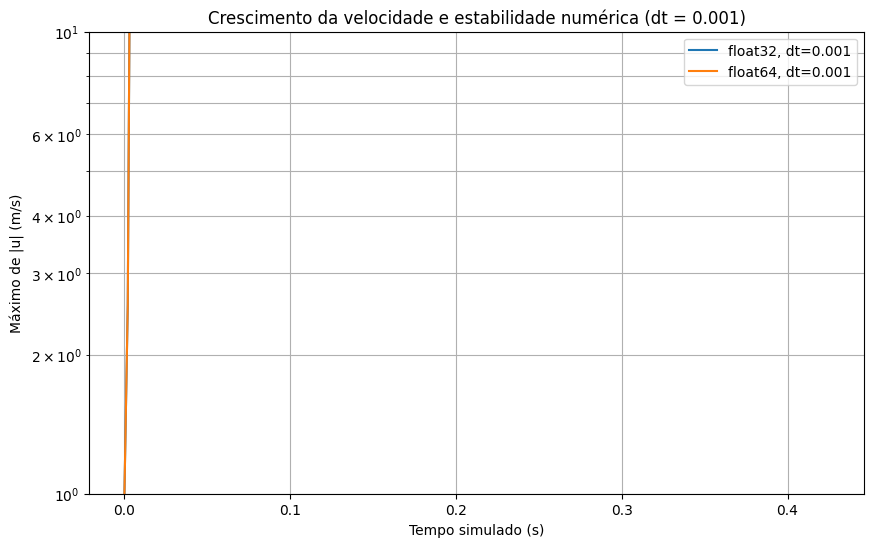

In [17]:
import matplotlib.pyplot as plt
import numpy as np


def verificar_estabilidade(dt, pontos=41):
    # Constantes do problema
    H = 0.01
    nu = 1e-4

    # Espaçamento da malha
    dy = H / (pontos - 1)

    # Maior passo de tempo permitido
    dt_max = (dy**2) / (2 * nu)

    # Número de estabilidade
    r = nu * dt / (dy**2)

    # Classificação
    if r <= 0.5:
        estabilidade = "ESTÁVEL"
    else:
        estabilidade = "INSTÁVEL"

    print("\n" + "=" * 55)
    print(f"Análise de estabilidade - {pontos} pontos")
    print("=" * 55)
    print(f"Δy        = {dy:.8f} m")
    print(f"Δt        = {dt:.8f} s")
    print(f"Δt máximo = {dt_max:.8f} s")
    print(f"r         = {r:.4f}")
    print(f"Resultado = {estabilidade}")
    print("=" * 55)

    return dy, dt_max, r, estabilidade


def simular(dt, tipo=np.float32, passos=2000, pontos=41):

    H = 0.01
    nu = 1e-4

    # Calcula e mostra a estabilidade antes da simulação
    dy, dt_max, r, estabilidade = verificar_estabilidade(dt, pontos)

    y = np.linspace(0, H, pontos)

    # Coeficientes no tipo numérico escolhido
    r_num = tipo(r)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]

    falha = None

    # Transforma avisos numéricos em exceções
    with np.errstate(over="raise", invalid="raise"):

        for passo in range(1, passos + 1):

            try:
                novo = u.copy()

                # Atualização da equação de difusão
                novo[1:-1] = u[1:-1] + r_num * (
                    u[2:] - dois * u[1:-1] + u[:-2]
                )

                # Verifica se apareceram valores infinitos ou NaN
                if not np.all(np.isfinite(novo)):
                    raise FloatingPointError("valor infinito ou NaN encontrado")

            except FloatingPointError as erro:

                falha = passo

                print(
                    f"\nOverflow/falha numérica!"
                    f"\nTipo: {tipo.__name__}"
                    f"\ndt = {dt}"
                    f"\nPasso = {passo}"
                    f"\nt = {passo * dt:.6f} s"
                    f"\nErro: {erro}"
                )

                break

            u = novo

            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:

        print(
            f"\n✓ Simulação concluída:"
            f"\nTipo: {tipo.__name__}"
            f"\ndt = {dt}"
            f"\n{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "dy": dy,
        "dt_max": dt_max,
        "r": float(r),
        "estabilidade": estabilidade,
        "falha": falha,
    }


# ============================================================
# LIMITES DOS TIPOS NUMÉRICOS
# ============================================================

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)


# ============================================================
# EXECUÇÃO APENAS PARA dt = 0.001
# ============================================================

resultados = {}
dt = 0.001

for tipo in (np.float32, np.float64):

    nome = f"{tipo.__name__}, dt={dt}"

    resultados[nome] = simular(
        dt=dt, tipo=tipo, passos=2000, pontos=41
    )


# ============================================================
# TABELA FINAL
# ============================================================

print("\n\n")
print("=" * 85)
print("TABELA DE RESULTADOS")
print("=" * 85)

print(
    f"{'Tipo':<12}"
    f"{'dt (s)':<12}"
    f"{'Δy (m)':<15}"
    f"{'dt máx. (s)':<15}"
    f"{'r':<10}"
    f"{'Estabilidade':<15}"
    f"{'Overflow':<10}"
)

print("-" * 85)

for nome, resultado in resultados.items():

    tipo = nome.split(",")[0]

    overflow = (
        "Sim" if resultado["falha"] is not None else "Não"
    )

    print(
        f"{tipo:<12}"
        f"{dt:<12.4f}"
        f"{resultado['dy']:<15.8f}"
        f"{resultado['dt_max']:<15.8f}"
        f"{resultado['r']:<10.3f}"
        f"{resultado['estabilidade']:<15}"
        f"{overflow:<10}"
    )


# ============================================================
# GRÁFICO
# ============================================================

plt.figure(figsize=(10, 6))

for nome, resultado in resultados.items():

    plt.semilogy(
        resultado["tempos"], resultado["maximos"], label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s)")
plt.title("Crescimento da velocidade e estabilidade numérica (dt = 0.001)")
plt.grid(True, which="both")
plt.legend()

plt.show()

### 5. Refinamento da malha: novo espaçamento e limite de estabilidade

Para analisar o efeito do refinamento da malha, aumentamos o número de pontos de **21 para 41**. O domínio continua com:

$$
H = 0,01\ m
$$

O novo espaçamento entre os pontos é calculado por:

$$
\Delta y = \frac{H}{N-1}
$$

Substituindo \(H=0,01\) m e \(N=41\):

$$
\Delta y = \frac{0,01}{41-1}
$$

$$
\boxed{\Delta y = 0,00025\ m}
$$

Portanto, ao aumentar a quantidade de pontos de 21 para 41, o espaçamento da malha é reduzido pela metade.

---

### Novo limite de estabilidade

A condição de estabilidade do método é:

$$
r = \frac{\nu\Delta t}{(\Delta y)^2} \leq \frac{1}{2}
$$

Logo, o maior passo de tempo permitido é:

$$
\Delta t_{\max} = \frac{(\Delta y)^2}{2\nu}
$$

Utilizando:

$$
\Delta y = 0,00025\ m
$$

e

$$
\nu = 10^{-4}\ m^2/s
$$

temos:

$$
\Delta t_{\max}
=
\frac{(0,00025)^2}{2(10^{-4})}
$$

$$
\Delta t_{\max}
=
\frac{6,25\times10^{-8}}{2\times10^{-4}}
$$

$$
\boxed{\Delta t_{\max}=0,0003125\ s}
$$

Assim, com 41 pontos, o novo limite de estabilidade é:

$$
\boxed{\Delta t_{\max}=3,125\times10^{-4}\ s}
$$

---

### Execução da simulação

Ao realizar o refinamento da malha, é importante observar que o limite de estabilidade diminuiu de:

$$
0,00125\ s
$$

para:

$$
0,0003125\ s
$$

Isso acontece porque o limite depende do **quadrado do espaçamento**:

$$
\Delta t_{\max}\propto(\Delta y)^2
$$

Como o espaçamento foi reduzido pela metade, o limite de estabilidade foi reduzido por um fator de quatro.

#### Mantendo \(\Delta t=0,001\ s\)

Se mantivermos o mesmo passo de tempo utilizado anteriormente, temos:

$$
r=
\frac{10^{-4}(0,001)}{(0,00025)^2}
$$

$$
r=1,6
$$

Como:

$$
1,6 > 0,5
$$

a simulação é **instável**.

Portanto, apesar de a malha ter sido refinada e possuir mais pontos, manter o mesmo \(\Delta t\) utilizado anteriormente faz com que a simulação fique ainda mais instável.

Na execução, isso é observado pelo crescimento artificial dos valores da velocidade. Assim como ocorreu no Caso B anterior, os erros numéricos são amplificados a cada iteração, fazendo com que a solução se afaste do comportamento físico esperado e eventualmente possa ocorrer overflow.

---

### Interpretação do resultado

O refinamento da malha **não significa que podemos manter o mesmo passo de tempo**. Pelo contrário: quanto menor for o espaçamento \(\Delta y\), menor deverá ser o \(\Delta t\) para que a condição de estabilidade seja respeitada.

Para os 41 pontos:

$$
\boxed{\Delta y=0,00025\ m}
$$

$$
\boxed{\Delta t_{\max}=0,0003125\ s}
$$

e, utilizando \(\Delta t=0,001\ s\):

$$
\boxed{r=1,6}
$$

Portanto, o resultado esperado é uma **solução instável**, com crescimento artificial dos valores e possível explosão numérica.

Para obter uma simulação estável com a malha refinada, é necessário utilizar um passo de tempo menor ou igual a \(0,0003125\) s. Por exemplo, utilizando:

$$
\Delta t=0,0002\ s
$$

obtemos:

$$
r=
\frac{10^{-4}(0,0002)}{(0,00025)^2}
=0,32
$$

Como \(0,32<0,5\), essa configuração é **estável**.

### Conclusão

O refinamento da malha melhora a resolução espacial da solução, mas também torna a condição de estabilidade mais restritiva. Ao passar de 21 para 41 pontos, o espaçamento caiu pela metade e o limite de \(\Delta t\) caiu para um quarto do valor anterior.

Dessa forma, **uma malha mais refinada exige um passo de tempo menor para manter a estabilidade do método**.


Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308

Análise de estabilidade - 41 pontos
Δy        = 0.00025000 m
Δt        = 0.00031000 s
Δt máximo = 0.00031250 s
r         = 0.4960
Resultado = ESTÁVEL

✓ Simulação concluída:
Tipo: float32
dt = 0.00031
2000 passos sem overflow.

Análise de estabilidade - 41 pontos
Δy        = 0.00025000 m
Δt        = 0.00031000 s
Δt máximo = 0.00031250 s
r         = 0.4960
Resultado = ESTÁVEL

✓ Simulação concluída:
Tipo: float64
dt = 0.00031
2000 passos sem overflow.



TABELA DE RESULTADOS
Tipo        dt (s)      Δy (m)         dt máx. (s)    r         Estabilidade   Overflow  
-------------------------------------------------------------------------------------
float32     0.0003      0.00025000     0.00031250     0.496     ESTÁVEL        Não       
float64     0.0003      0.00025000     0.00031250     0.496     ESTÁVEL        Não       


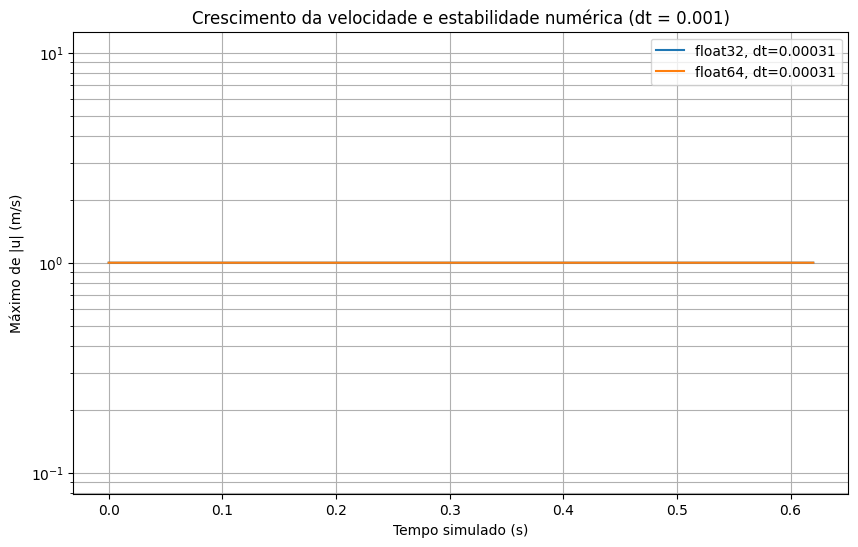

In [18]:
import matplotlib.pyplot as plt
import numpy as np


def verificar_estabilidade(dt, pontos=41):
    # Constantes do problema
    H = 0.01
    nu = 1e-4

    # Espaçamento da malha
    dy = H / (pontos - 1)

    # Maior passo de tempo permitido
    dt_max = (dy**2) / (2 * nu)

    # Número de estabilidade
    r = nu * dt / (dy**2)

    # Classificação
    if r <= 0.5:
        estabilidade = "ESTÁVEL"
    else:
        estabilidade = "INSTÁVEL"

    print("\n" + "=" * 55)
    print(f"Análise de estabilidade - {pontos} pontos")
    print("=" * 55)
    print(f"Δy        = {dy:.8f} m")
    print(f"Δt        = {dt:.8f} s")
    print(f"Δt máximo = {dt_max:.8f} s")
    print(f"r         = {r:.4f}")
    print(f"Resultado = {estabilidade}")
    print("=" * 55)

    return dy, dt_max, r, estabilidade


def simular(dt, tipo=np.float32, passos=2000, pontos=41):

    H = 0.01
    nu = 1e-4

    # Calcula e mostra a estabilidade antes da simulação
    dy, dt_max, r, estabilidade = verificar_estabilidade(dt, pontos)

    y = np.linspace(0, H, pontos)

    # Coeficientes no tipo numérico escolhido
    r_num = tipo(r)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]

    falha = None

    # Transforma avisos numéricos em exceções
    with np.errstate(over="raise", invalid="raise"):

        for passo in range(1, passos + 1):

            try:
                novo = u.copy()

                # Atualização da equação de difusão
                novo[1:-1] = u[1:-1] + r_num * (
                    u[2:] - dois * u[1:-1] + u[:-2]
                )

                # Verifica se apareceram valores infinitos ou NaN
                if not np.all(np.isfinite(novo)):
                    raise FloatingPointError("valor infinito ou NaN encontrado")

            except FloatingPointError as erro:

                falha = passo

                print(
                    f"\nOverflow/falha numérica!"
                    f"\nTipo: {tipo.__name__}"
                    f"\ndt = {dt}"
                    f"\nPasso = {passo}"
                    f"\nt = {passo * dt:.6f} s"
                    f"\nErro: {erro}"
                )

                break

            u = novo

            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:

        print(
            f"\n✓ Simulação concluída:"
            f"\nTipo: {tipo.__name__}"
            f"\ndt = {dt}"
            f"\n{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "dy": dy,
        "dt_max": dt_max,
        "r": float(r),
        "estabilidade": estabilidade,
        "falha": falha,
    }


# ============================================================
# LIMITES DOS TIPOS NUMÉRICOS
# ============================================================

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)


# ============================================================
# EXECUÇÃO APENAS PARA dt = 0.001
# ============================================================

resultados = {}
dt = 0.0003100

for tipo in (np.float32, np.float64):

    nome = f"{tipo.__name__}, dt={dt}"

    resultados[nome] = simular(
        dt=dt, tipo=tipo, passos=2000, pontos=41
    )


# ============================================================
# TABELA FINAL
# ============================================================

print("\n\n")
print("=" * 85)
print("TABELA DE RESULTADOS")
print("=" * 85)

print(
    f"{'Tipo':<12}"
    f"{'dt (s)':<12}"
    f"{'Δy (m)':<15}"
    f"{'dt máx. (s)':<15}"
    f"{'r':<10}"
    f"{'Estabilidade':<15}"
    f"{'Overflow':<10}"
)

print("-" * 85)

for nome, resultado in resultados.items():

    tipo = nome.split(",")[0]

    overflow = (
        "Sim" if resultado["falha"] is not None else "Não"
    )

    print(
        f"{tipo:<12}"
        f"{dt:<12.4f}"
        f"{resultado['dy']:<15.8f}"
        f"{resultado['dt_max']:<15.8f}"
        f"{resultado['r']:<10.3f}"
        f"{resultado['estabilidade']:<15}"
        f"{overflow:<10}"
    )


# ============================================================
# GRÁFICO
# ============================================================

plt.figure(figsize=(10, 6))

for nome, resultado in resultados.items():

    plt.semilogy(
        resultado["tempos"], resultado["maximos"], label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s)")
plt.title("Crescimento da velocidade e estabilidade numérica (dt = 0.001)")
plt.grid(True, which="both")
plt.legend()

plt.show()

# 6. Verificação do perfil de velocidade

A solução estacionária fornecida na atividade é:

uₑₛₜ(y) = U(1 − y/H)

Ela representa o regime estacionário, não todo o transiente. Por isso, usamos uma simulação suficientemente longa antes de comparar os perfis.

Erro máximo E∞ = 0.00139135 m/s


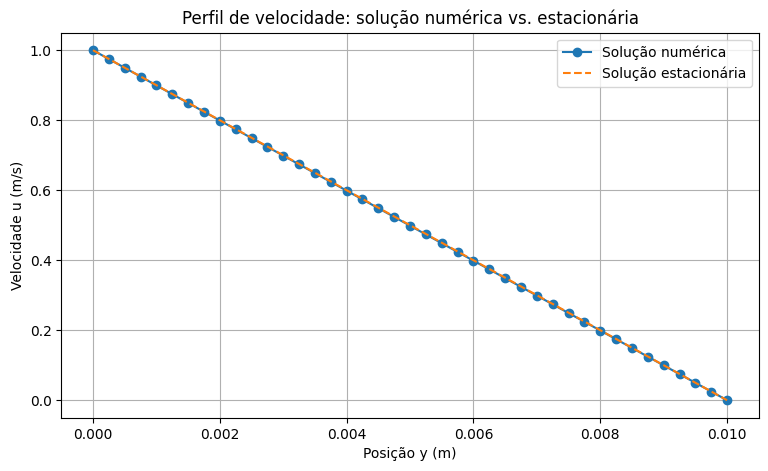

In [20]:
# Perfil estacionário
U = 1.0
H = 0.01

y = resultado["y"]
u = resultado["u"]

uest = U * (1 - y / H)

# Erro máximo
E_inf = np.max(np.abs(u - uest))

print(f"Erro máximo E∞ = {E_inf:.8f} m/s")

# Gráfico
plt.figure(figsize=(9, 5))

plt.plot(
    y,
    u,
    marker="o",
    label="Solução numérica"
)

plt.plot(
    y,
    uest,
    linestyle="--",
    label="Solução estacionária"
)

plt.xlabel("Posição y (m)")
plt.ylabel("Velocidade u (m/s)")
plt.title("Perfil de velocidade: solução numérica vs. estacionária")
plt.grid(True)
plt.legend()

plt.show()

### Conclusão

A análise mostrou que a estabilidade do método explícito utilizado na simulação depende diretamente da relação entre o passo de tempo e o espaçamento da malha, representada pelo parâmetro:

$$
r=\frac{\nu\Delta t}{\Delta y^2}
$$

Para a malha inicial com 21 pontos, obteve-se:

$$
\Delta y=0,0005\ m
$$

e

$$
\Delta t_{\max}=0,00125\ s
$$

Dessa forma, o **Caso A**, com \(\Delta t=0,001\ s\) e \(r=0,4\), é estável, enquanto o **Caso B**, com \(\Delta t=0,002\ s\) e \(r=0,8\), é instável.

A instabilidade numérica observada no Caso B provoca um crescimento artificial da velocidade, fazendo com que os valores ultrapassem significativamente o limite físico:

$$
0\leq u\leq1\ m/s
$$

Esse crescimento não representa o comportamento real do fluido, mas sim a amplificação dos erros numéricos causada pela violação da condição de estabilidade. O overflow ocorre quando esses valores crescem além da capacidade de representação do tipo numérico utilizado.

A comparação entre `float32` e `float64` mostrou que a mudança do tipo numérico **não elimina a instabilidade**. O `float64`, por possuir uma faixa de representação significativamente maior, pode suportar mais iterações antes de ocorrer overflow, mas a solução continua instável quando:

$$
r>0,5
$$

Portanto, o aumento da precisão numérica não corrige a causa da instabilidade.

No refinamento da malha para 41 pontos, o espaçamento diminuiu para:

$$
\Delta y=0,00025\ m
$$

e o novo limite de estabilidade passou a ser:

$$
\Delta t_{\max}=0,0003125\ s
$$

Assim, manter \(\Delta t=0,001\ s\) tornou a simulação ainda mais instável, pois o novo valor de \(r\) passou a ser:

$$
r=1,6
$$

Para recuperar a estabilidade, foi necessário reduzir o passo de tempo para um valor inferior ao novo limite, como \(\Delta t=0,0002\ s\), resultando em:

$$
r=0,32
$$

Por fim, em uma execução estável e suficientemente longa, o perfil numérico de velocidade deve se aproximar da solução estacionária:

$$
u_{est}(y)=U\left(1-\frac{y}{H}\right)
$$

A diferença máxima \(E_\infty\) permite quantificar essa aproximação. Caso o erro ainda seja significativo, ele pode estar relacionado ao fato de o transiente ainda não ter terminado, uma vez que a expressão analítica fornecida representa o regime estacionário, e não o comportamento durante todo o período transiente.

Conclui-se, portanto, que a alteração que efetivamente corrige a causa da falha é a **redução do passo de tempo de modo a satisfazer a condição de estabilidade**:

$$
\boxed{r\leq0,5}
$$

O refinamento da malha, embora aumente a resolução espacial, exige um passo de tempo ainda menor para manter a estabilidade.
